# Прогноз РТО магазинов Пятёрочка на ноябрь

В этом ноутбуке решается задача прогнозирования розничного товарооборота магазинов сети Пятёрочка на следующий месяц. Наш таргет это РТО - это выручка магазина за период времени, то есть сумма цен всех проданных товаров. В соревновании требуется построить прогноз РТО на ноябрь для каждого магазина.

## Данные

В обучающей выборке train (1).csv содержатся исторические данные по магазинам за 10 месяцев. Каждая строка соответствует одному магазину в одном месяце.

Основные поля:

- new_id - идентификатор магазина
- Месяц - номер месяца
- РТО - целевая переменная, розничный товарооборот магазина за месяц
- остальные признаки - социально-географические и операционные характеристики магазина.


Структура задачи

В данных представлены 20615 магазинов. Для каждого магазина известна история РТО за месяцы с 1 по 10. Необходимо спрогнозировать РТО на месяц 11, который в задаче соответствует ноябрю. Таким образом, задача является задачей прогнозирования коротких панельных временных рядов: много магазинов, но короткая история по каждому из них. Метрика, качество решения оценивается по MAPE, она показывает среднюю абсолютную ошибку прогноза в процентах относительно фактического значения. Так как по каждому магазину доступно только 10 исторических точек, классические модели временных рядов вроде ARIMA или Prophet могут быть нестабильны. Поэтому я выбрал основной подход, как построить общую модель для всех магазинов, используя следующие признаки:

- лаги РТО
- дневной РТО с учётом числа дней в месяце
- темпы роста между месяцами
- rolling-статистики
- статичные признаки магазина
- календарные признаки.


## План ноутбука

Идём от простого к сильному: сначала проверяем данные и базовую динамику, потом собираем признаки, сравниваем несколько моделей и в конце делаем ансамбль. Главная защита от самообмана здесь — rolling validation: каждый месяц проверяем так, будто он ещё не известен.


In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn tqdm

  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl (9.7 MB)
Using cached numpy-2.4


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Подготовка окружения

Эта ячейка ставит базовые библиотеки для анализа и моделей. Если окружение уже настроено, повторный запуск обычно ничего не меняет по сути, но после установки новых пакетов лучше перезапустить kernel.


In [5]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path(".")

TRAIN_PATH = DATA_DIR / "train (1).csv"
TEST_PATH = DATA_DIR / "test (1).csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

month_col = "Месяц"
target_col = "РТО"

print("train shape:", train.shape)
print("test shape:", test.shape)

display(train.head())
print("\n")
display(test.head())

print("train columns:")
for col in train.columns:
    print(f"- {col}: {train[col].dtype}")



train shape: (206150, 19)
test shape: (20615, 2)


,new_id,Месяц,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,1,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,22041969.33
1,0,2,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,23268490.57
2,0,3,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,24487732.21
3,0,4,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,23981980.29
4,0,5,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,26608343.78


,new_id,rto
0,0,3.350398e+07
1,1,3.350398e+07
2,2,3.350398e+07
3,3,3.350398e+07
4,4,3.350398e+07


train columns:
- new_id: int64
- Месяц: int64
- Дата открытия, категориальный: str
- Торговая площадь, категориальный: str
- Населенный пункт: str
- Регион: str
- Численность населения: int64
- Количество домохозяйств: int64
- Трафик пеший, в час: int64
- Трафик авто, в час: int64
- Маркетплейсы, доставки, постаматы (100 м): int64
- Медицинские уч. и аптеки (300 м): int64
- Школы (300 м): int64
- Остановки (300 м): int64
- Продуктовые магазины (500 м): int64
- Пятерочки (500 м): int64
- Количество касс: int64
- Флаг алкогольной лицензии: int64
- РТО: float64

months: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Unique train stores: 20615
Unique test stores 20615

missing values in train: 0
missing values in test: 0

duplicated train rows: 0
duplicated test rows: 0

stores with full history (10 rows): 20615
min rows per store: 10
max rows per store: 10

train ids not in test: 0
test ids not in train: 

## Загрузка данных

Загружаем обучающую таблицу и шаблон отправки. Сразу фиксируем имена ключевых колонок, чтобы дальше не писать строковые названия по всему ноутбуку.


In [6]:
print("\nmonths:", sorted(train[month_col].unique()))
print("Unique train stores:", train["new_id"].nunique())
print("Unique test stores", test["new_id"].nunique())

print("\nmissing values in train:", train.isna().sum().sum())
print("missing values in test:", test.isna().sum().sum())

print("\nduplicated train rows:", train.duplicated().sum())
print("duplicated test rows:", test.duplicated().sum())

rows_per_store = train.groupby("new_id").size()

print("\nstores with full history (10 rows):", (rows_per_store == 10).sum())
print("min rows per store:", rows_per_store.min())
print("max rows per store:", rows_per_store.max())

train_ids = set(train["new_id"])
test_ids = set(test["new_id"])

print("\ntrain ids not in test:", len(train_ids - test_ids))
print("test ids not in train:", len(test_ids - train_ids))



months: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Unique train stores: 20615
Unique test stores 20615

missing values in train: 0
missing values in test: 0

duplicated train rows: 0
duplicated test rows: 0

stores with full history (10 rows): 20615
min rows per store: 10
max rows per store: 10

train ids not in test: 0
test ids not in train: 0


## Быстрый аудит структуры

Проверяем, что данные действительно выглядят как панель: один магазин наблюдается несколько месяцев подряд. Здесь же смотрим пропуски, дубли и совпадение магазинов между train и test.


Проверка train/test и возможных утечек: понять, что лежит в test['rto']. Нам нужно сравнить распределение РТО в train и test, чтобы понять, есть ли там утечки. Если в test['rto'] есть реальные значения РТО, то это может означать, что мы можем использовать эти данные для обучения модели, что будет нарушать правила соревнования. Поэтому важно проверить, что test['rto'] не содержит реальных значений РТО и используется только как шаблон для сабмита.

In [8]:
wide_rto = train.pivot(index="new_id", columns=month_col, values=target_col)

test_sorted = test.sort_values("new_id").reset_index(drop=True)
wide_sorted = wide_rto.sort_index()

checks = pd.DataFrame({
    "new_id": test_sorted["new_id"],
    "test_rto": test_sorted["rto"],
    "month_10_rto": wide_sorted[10].to_numpy(),
    "mean_all_months_rto": wide_sorted.mean(axis=1).to_numpy(),
    "mean_month_10_rto": wide_sorted[10].mean(),
    "median_month_10_rto": wide_sorted[10].median(),
})

checks.head(20)

,new_id,test_rto,month_10_rto,mean_all_months_rto,mean_month_10_rto,median_month_10_rto
0,0,3.350398e+07,27145282.92,2.530544e+07,3.350398e+07,28658265.08
1,1,3.350398e+07,32336271.96,2.518625e+07,3.350398e+07,28658265.08
2,2,3.350398e+07,37473470.94,3.728539e+07,3.350398e+07,28658265.08
3,3,3.350398e+07,69136935.96,5.966712e+07,3.350398e+07,28658265.08
4,4,3.350398e+07,42004513.79,4.024331e+07,3.350398e+07,28658265.08
5,5,3.350398e+07,15078548.80,1.684418e+07,3.350398e+07,28658265.08
6,6,3.350398e+07,75756838.64,7.256814e+07,3.350398e+07,28658265.08
7,7,3.350398e+07,30195116.50,3.122218e+07,3.350398e+07,28658265.08
8,8,3.350398e+07,16940370.94,1.940894e+07,3.350398e+07,28658265.08
9,9,3.350398e+07,34406333.07,3.521235e+07,3.350398e+07,28658265.08


насколько test['rto'] похож на baseline

In [9]:
baseline_checks = {
    "test_rto_unique_values": test["rto"].nunique(),
    "test_rto_mean": test["rto"].mean(),
    "month_10_mean": train.loc[train[month_col] == 10, target_col].mean(),
    "all_train_mean": train[target_col].mean(),
    "test_equals_month_10_mean": np.allclose(
        test["rto"],
        train.loc[train[month_col] == 10, target_col].mean()
    ),
    "test_equals_all_train_mean": np.allclose(
        test["rto"],
        train[target_col].mean()
    ),
}

baseline_checks


{'test_rto_unique_values': 1,
 'test_rto_mean': np.float64(33503980.259272866),
 'month_10_mean': np.float64(33503980.259272862),
 'all_train_mean': np.float64(32727246.5916424),
 'test_equals_month_10_mean': True,
 'test_equals_all_train_mean': False}

test['rto'] это не реальные ответы, а шаблонный baseline. Во всех строках стоит одно и то же значение средний РТО за 10-й месяц по всем магазинам. Поэтому этот столбец используем только как пример формата отправки.

# EDA

## Что смотрим в EDA

В EDA нас интересуют только вещи, которые могут помочь прогнозу: общий уровень РТО, движение по месяцам, календарь, скачки и различия между сегментами магазинов. Лишние графики не строим, чтобы ноутбук оставался рабочим.

In [10]:
month_stats = (
    train
    .groupby(month_col)[target_col]
    .agg(["mean", "median", "sum"])
    .round(2)
)

month_stats

,mean,median,sum
Месяц,,,
1,28867866.18,24526483.83,5.951111e+11
2,29718297.26,25121925.38,6.126427e+11
3,33044647.42,27978843.47,6.812154e+11
4,32539417.99,27754394.57,6.708001e+11
5,34339602.87,29460545.48,7.079109e+11
6,33959708.81,29174830.55,7.000794e+11
7,35025249.97,30144958.49,7.220455e+11
8,33890807.38,29188941.49,6.986590e+11
9,32382887.77,27727269.75,6.675732e+11


## Динамика по месяцам

Считаем среднее, медиану и суммарный РТО по каждому месяцу. Это помогает понять общий тренд сети и увидеть месяцы, где спрос заметно выбивается.


Text(0.5, 1.0, 'Распределение РТО в train')

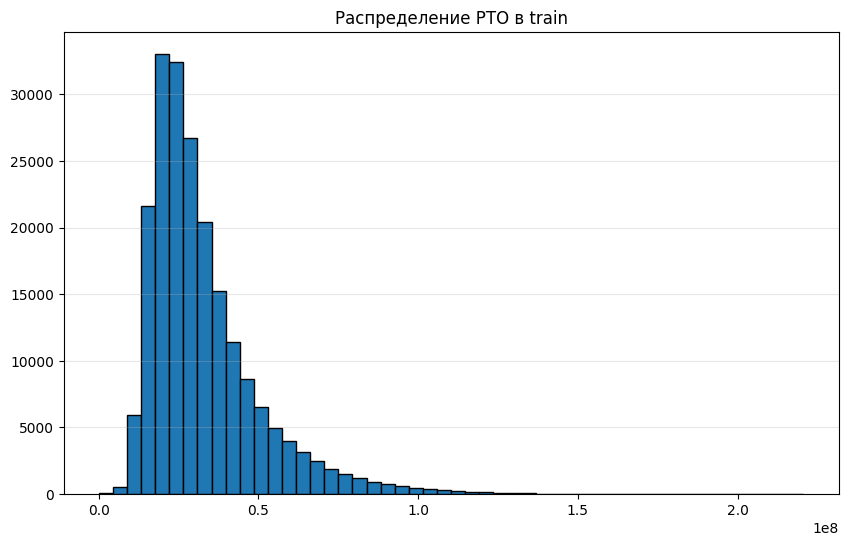

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(train[target_col], bins=50, edgecolor="black")
plt.grid(axis='y', alpha=0.3)
plt.title("Распределение РТО в train")

<Axes: title={'center': 'Средний и медианный РТО по месяцам'}, xlabel='Месяц'>

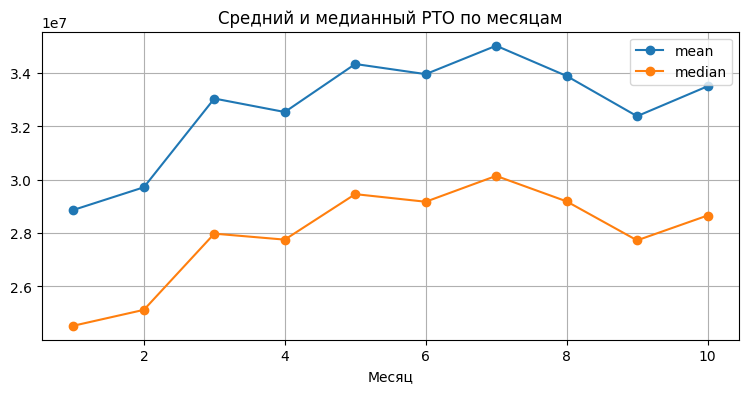

In [11]:
month_stats[["mean", "median"]].plot(
    figsize=(9, 4),
    marker="o",
    title="Средний и медианный РТО по месяцам",
    grid=True,
)

In [14]:
days_in_month = {
    1: 31,
    2: 28,
    3: 31,
    4: 30,
    5: 31,
    6: 30,
    7: 31,
    8: 31,
    9: 30,
    10: 31,
    11: 30,
}

train_daily = train.copy()
train_daily["days_in_month"] = train_daily[month_col].map(days_in_month)
train_daily["daily_rto"] = train_daily[target_col] / train_daily["days_in_month"]

train_daily.head(12)


,new_id,Месяц,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час",...,Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО,days_in_month,daily_rto
0,0,1,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,...,6,0,0,2,0,10,1,22041969.33,31,711031.268710
1,0,2,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,...,6,0,0,2,0,10,1,23268490.57,28,831017.520357
2,0,3,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,...,6,0,0,2,0,10,1,24487732.21,31,789926.845484
3,0,4,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,...,6,0,0,2,0,10,1,23981980.29,30,799399.343000
4,0,5,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,...,6,0,0,2,0,10,1,26608343.78,31,858333.670323
5,0,6,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,...,6,0,0,2,0,10,1,26148681.55,30,871622.718333
6,0,7,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,...,6,0,0,2,0,10,1,27292985.79,31,880418.896452
7,0,8,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,...,6,0,0,2,0,10,1,27712633.36,31,893955.914839
8,0,9,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,...,6,0,0,2,0,10,1,24366310.39,30,812210.346333
9,0,10,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,...,6,0,0,2,0,10,1,27145282.92,31,875654.287742


## Дневной РТО

Месячная выручка зависит от количества дней в месяце, поэтому отдельно считаем РТО в пересчёте на один день. Это важно для прогноза ноября: в ноябре 30 дней, а в октябре 31.


In [15]:
daily_month_stats = (
    train_daily.groupby(month_col)["daily_rto"]
    .agg(["mean", "median"])
    .round(2)
)

daily_month_stats

,mean,median
Месяц,,
1,931221.49,791176.90
2,1061367.76,897211.62
3,1065956.37,902543.34
4,1084647.27,925146.49
5,1107729.12,950340.18
6,1131990.29,972494.35
7,1129846.77,972418.02
8,1093251.85,941578.76
9,1079429.59,924242.32


In [31]:
monthly_ratios = wide_rto.pct_change(axis=1).iloc[:, 1:] + 1

ratio_stats = monthly_ratios.agg(["mean", "median"]).T.round(4)
ratio_stats

,mean,median
Месяц,,
2,1.1291,1.0244
3,1.1183,1.1105
4,0.9931,0.9771
5,1.0622,1.0478
6,0.9939,0.9751
7,1.0370,1.0302
8,0.9726,0.9726
9,0.9614,0.9652
10,1.0387,1.0451


## Темпы роста

Ratio показывает, во сколько раз РТО изменился относительно предыдущего месяца. Это удобнее обычной разницы, потому что магазины сильно отличаются по масштабу.


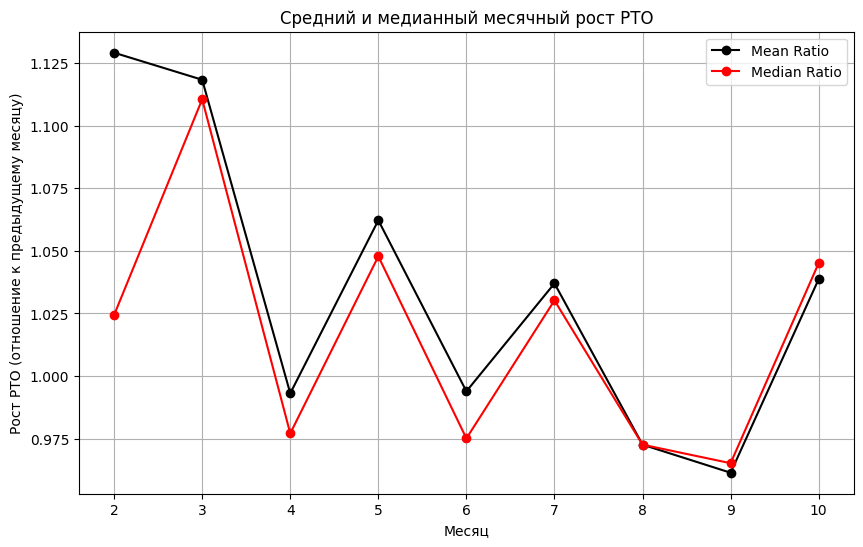

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(ratio_stats.index, ratio_stats["mean"], marker="o", label="Mean Ratio",color="black")
plt.plot(ratio_stats.index, ratio_stats["median"], marker="o", label="Median Ratio",color="red")
plt.grid()
plt.title("Средний и медианный месячный рост РТО")
plt.xlabel("Месяц")
plt.ylabel("Рост РТО (отношение к предыдущему месяцу)")
plt.legend()
plt.show()


In [35]:
train[target_col].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).round(2)

count    2.061500e+05
mean     3.272725e+07
std      1.768909e+07
min      1.619487e+04
1%       1.084686e+07
5%       1.436472e+07
25%      2.086432e+07
50%      2.791845e+07
75%      3.923328e+07
95%      6.795803e+07
99%      9.683637e+07
max      2.205870e+08
Name: РТО, dtype: float64

In [38]:
segment_cols = [
    "Регион",
    "Торговая площадь, категориальный",
    "Дата открытия, категориальный",
]

for col in segment_cols:
    display(
        train
        .groupby(col)[target_col]
        .agg(["count", "mean", "median"])
        .sort_values("median", ascending=False)
        .head(15)
        .round(2)
    )

,count,mean,median
Регион,,,
Ямало-Ненецкий АО,650,52191740.91,51427747.59
Санкт-Петербург г,5250,55808905.76,50202217.98
Москва г,14230,51960832.21,46570736.38
Приморский край,320,42177380.17,42183269.01
Московская обл,19300,43094362.07,38613406.06
Ленинградская обл,4280,42934065.94,37129659.54
Калужская обл,2310,39162102.90,35999192.22
Хабаровский край,670,36848333.60,34988917.33
Мурманская обл,1650,38109209.59,34960793.04


,count,mean,median
"Торговая площадь, категориальный",,,
Очень большой,4940,72552417.09,68840192.17
Большой,41490,45077021.66,40891459.25
Средний,116500,29794363.17,26871886.66
Маленький,43220,24225451.32,22164882.42


,count,mean,median
"Дата открытия, категориальный",,,
Открыт давно,9140,56470213.84,52505620.66
Средний по возрасту,134040,32174266.10,27919103.35
Новый,62970,30458083.24,26251177.36


## Сегменты и скачки

Смотрим, как РТО отличается по региону, площади и возрасту магазина, а также насколько часто встречаются резкие месячные скачки. Эти наблюдения потом превращаются в признаки для модели.


In [39]:
ratio_extremes = pd.DataFrame({
    "min_ratio": monthly_ratios.min(axis=1),
    "max_ratio": monthly_ratios.max(axis=1),
})

ratio_extremes.describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).round(4)

,min_ratio,max_ratio
count,20615.0000,20615.0000
mean,0.8891,1.2743
std,0.0830,6.8020
min,0.0009,1.0054
1%,0.5189,1.0581
5%,0.7477,1.0750
50%,0.9105,1.1283
95%,0.9635,1.3962
99%,0.9807,2.4006
max,1.0497,941.7650


In [40]:
big_jumps = ratio_extremes[
    (ratio_extremes["min_ratio"] < 0.7) |
    (ratio_extremes["max_ratio"] > 1.5)
]

len(big_jumps)

1013

#  Метрика и схема rolling validation

## Rolling validation

Настоящих ответов за ноябрь нет, поэтому проверяемся на уже известных месяцах. Для каждого месяца используем только прошлое, чтобы имитировать реальный прогноз будущего месяца.


In [63]:
def mape(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred) / y_true) * 100


validation_months = [6, 7, 8, 9, 10]
ml_validation_months = validation_months[1:]

month_weights = {
    6: 0.10,
    7: 0.15,
    8: 0.20,
    9: 0.25,
    10: 0.30,
}

In [64]:
def score_validation(predictions, months=None):
    months = validation_months if months is None else months
    scores = []

    for month in months:
        y_true = wide_rto[month]
        y_pred = predictions[month]

        scores.append({
            "month": month,
            "mape": mape(y_true, y_pred),
            "weight": month_weights[month],
        })

    scores = pd.DataFrame(scores)
    weighted_mape = (scores["mape"] * scores["weight"]).sum() / scores["weight"].sum()

    return scores.round(4), round(weighted_mape, 4)

# Base feature engineering

In [65]:
static_cols = [
    col for col in train.columns
    if col not in ["new_id", month_col, target_col]
]

static_features = (
    train
    .sort_values(["new_id", month_col])
    .drop_duplicates("new_id")
    .set_index("new_id")[static_cols]
)

static_features.head()

,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии
new_id,,,,,,,,,,,,,,,,
0,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1
1,Средний по возрасту,Средний,Екатеринбург г,Свердловская обл,1443297,3417,149,204,1,2,2,3,6,1,9,1
2,Средний по возрасту,Маленький,Дубна г,Московская обл,75056,2050,80,144,11,0,1,1,0,0,7,1
3,Средний по возрасту,Большой,Подольск г,Московская обл,354166,3460,133,473,2,6,0,3,4,0,8,1
4,Средний по возрасту,Средний,Москва г,Москва г,12706550,6255,117,302,2,5,0,11,8,3,11,1


## Признаки из прошлого

Для каждого прогнозируемого месяца собираем лаги, дневной РТО, rolling-статистики, темпы роста и календарные признаки. Важно, что функция не берёт данные из самого прогнозируемого месяца, иначе была бы утечка.


In [66]:
def make_features(target_month):
    features = pd.DataFrame(index=wide_rto.index)

    for lag in [1, 2, 3, 4, 5]:
        month = target_month - lag
        features[f"rto_lag_{lag}"] = wide_rto[month]
        features[f"daily_rto_lag_{lag}"] = wide_rto[month] / days_in_month[month]

    daily_lags = features[[f"daily_rto_lag_{lag}" for lag in [1, 2, 3]]]

    features["daily_rto_mean_3"] = daily_lags.mean(axis=1)
    features["daily_rto_median_3"] = daily_lags.median(axis=1)
    features["daily_rto_std_3"] = daily_lags.std(axis=1)

    features["ratio_1"] = features["daily_rto_lag_1"] / features["daily_rto_lag_2"]
    features["ratio_2"] = features["daily_rto_lag_2"] / features["daily_rto_lag_3"]

    features["days_prev"] = days_in_month[target_month - 1]
    features["days_target"] = days_in_month[target_month]
    features["days_ratio"] = features["days_target"] / features["days_prev"]
    features["target_month"] = target_month

    features = features.join(static_features)

    return features.reset_index()


In [67]:
val_parts = []

for target_month in validation_months:
    part = make_features(target_month)
    part[target_col] = part["new_id"].map(wide_rto[target_month])
    part["target_month"] = target_month
    val_parts.append(part)

features_df = pd.concat(val_parts, ignore_index=True)

features_df.shape

(103075, 37)

In [68]:
drop_cols = ["new_id", target_col]

feature_cols = [col for col in features_df.columns if col not in drop_cols]

cat_cols = features_df[feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [col for col in feature_cols if col not in cat_cols]

len(feature_cols), len(num_cols), len(cat_cols)

C:\Users\Иван\AppData\Local\Temp\ipykernel_16720\492725553.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = features_df[feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()


(35, 31, 4)

## Подготовка матрицы признаков

Здесь отделяем признаки от таргета и делим колонки на числовые и категориальные. Категории дальше кодируются внутри pipeline, поэтому сама таблица остаётся читаемой.


# first model

In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

In [73]:
model = Pipeline([
    ("preprocess", ColumnTransformer([
        ("cat", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        ), cat_cols),
        ("num", "passthrough", num_cols),
    ])),
    ("model", HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42,
    )),
])

In [74]:
ml_predictions = {}

for month in ml_validation_months:
    train_part = features_df[features_df["target_month"] < month]
    valid_part = features_df[features_df["target_month"] == month]

    X_train = train_part[feature_cols]
    y_train = np.log1p(train_part[target_col])

    X_valid = valid_part[feature_cols]

    model.fit(X_train, y_train)

    pred = np.expm1(model.predict(X_valid))
    pred = np.maximum(pred, 0)

    ml_predictions[month] = pd.Series(pred, index=valid_part["new_id"])

In [75]:
ml_scores, ml_weighted_mape = score_validation(ml_predictions, ml_validation_months)

display(ml_scores)
ml_weighted_mape

,month,mape,weight
0,7,6.7959,0.15
1,8,7.4515,0.20
2,9,8.2656,0.25
3,10,5.3652,0.30


np.float64(6.8729)

# Тюнинг feature engineering

In [76]:
def make_features(target_month):
    features = pd.DataFrame(index=wide_rto.index)

    available_lags = [lag for lag in [1, 2, 3, 4, 5, 6] if target_month - lag >= 1]

    for lag in available_lags:
        month = target_month - lag
        features[f"rto_lag_{lag}"] = wide_rto[month]
        features[f"log_rto_lag_{lag}"] = np.log1p(wide_rto[month])
        features[f"daily_rto_lag_{lag}"] = wide_rto[month] / days_in_month[month]

    for window in [2, 3, 5]:
        lags = [lag for lag in range(1, window + 1) if f"daily_rto_lag_{lag}" in features]

        daily_lags = features[[f"daily_rto_lag_{lag}" for lag in lags]]

        features[f"daily_rto_mean_{window}"] = daily_lags.mean(axis=1)
        features[f"daily_rto_median_{window}"] = daily_lags.median(axis=1)
        features[f"daily_rto_std_{window}"] = daily_lags.std(axis=1)

    for lag in [1, 2, 3, 4, 5]:
        prev_col = f"daily_rto_lag_{lag + 1}"
        curr_col = f"daily_rto_lag_{lag}"

        if prev_col in features and curr_col in features:
            ratio = features[curr_col] / features[prev_col]
            features[f"daily_ratio_{lag}"] = ratio
            features[f"daily_ratio_{lag}_clip"] = ratio.clip(ratio.quantile(0.05), ratio.quantile(0.95))

    if {"daily_rto_lag_1", "daily_rto_lag_2", "daily_rto_lag_3"}.issubset(features.columns):
        features["trend_3"] = (
            features["daily_rto_lag_1"] - features["daily_rto_lag_3"]
        ) / features["daily_rto_lag_3"]

    if {"daily_rto_lag_1", "daily_rto_lag_5"}.issubset(features.columns):
        features["trend_5"] = (
            features["daily_rto_lag_1"] - features["daily_rto_lag_5"]
        ) / features["daily_rto_lag_5"]

    features["days_prev"] = days_in_month[target_month - 1]
    features["days_target"] = days_in_month[target_month]
    features["days_ratio"] = features["days_target"] / features["days_prev"]
    features["target_month"] = target_month

    features = features.join(static_features)

    return features.reset_index()


In [77]:
val_parts = []

for target_month in validation_months:
    part = make_features(target_month)
    part[target_col] = part["new_id"].map(wide_rto[target_month])
    part["target_month"] = target_month
    val_parts.append(part)

features_df = pd.concat(val_parts, ignore_index=True)

features_df.shape

(103075, 61)

In [78]:
drop_cols = ["new_id", target_col]

feature_cols = [col for col in features_df.columns if col not in drop_cols]

cat_cols = features_df[feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [col for col in feature_cols if col not in cat_cols]

len(feature_cols), len(num_cols), len(cat_cols)

C:\Users\Иван\AppData\Local\Temp\ipykernel_16720\492725553.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = features_df[feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()


(59, 55, 4)

In [79]:
model = Pipeline([
    ("preprocess", ColumnTransformer([
        ("cat", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        ), cat_cols),
        ("num", "passthrough", num_cols),
    ])),
    ("model", HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42,
    )),
])

In [80]:
ml_predictions = {}

for month in ml_validation_months:
    train_part = features_df[features_df["target_month"] < month]
    valid_part = features_df[features_df["target_month"] == month]

    X_train = train_part[feature_cols]
    y_train = np.log1p(train_part[target_col])

    X_valid = valid_part[feature_cols]

    model.fit(X_train, y_train)

    pred = np.expm1(model.predict(X_valid))
    pred = np.maximum(pred, 0)

    ml_predictions[month] = pd.Series(pred, index=valid_part["new_id"])

In [81]:
ml_scores, ml_weighted_mape = score_validation(ml_predictions, ml_validation_months)

display(ml_scores)
ml_weighted_mape

,month,mape,weight
0,7,7.0321,0.15
1,8,6.9209,0.20
2,9,7.6042,0.25
3,10,5.2935,0.30


np.float64(6.5868)

# Делаем шаг в сторону ансмабля 

## Сравнение моделей

Проверяем несколько разных алгоритмов на одной и той же rolling validation. Нас интересует не красота модели, а стабильный MAPE на будущих месяцах.


In [82]:
def validate_model(model, months=ml_validation_months):
    predictions = {}

    for month in months:
        train_part = features_df[features_df["target_month"] < month]
        valid_part = features_df[features_df["target_month"] == month]

        X_train = train_part[feature_cols]
        y_train = np.log1p(train_part[target_col])
        X_valid = valid_part[feature_cols]

        model.fit(X_train, y_train)

        pred = np.expm1(model.predict(X_valid))
        pred = np.maximum(pred, 0)

        predictions[month] = pd.Series(pred, index=valid_part["new_id"])

    scores, weighted_mape = score_validation(predictions, months)
    return predictions, scores, weighted_mape

In [83]:
hgb_predictions, hgb_scores, hgb_weighted_mape = validate_model(model)

display(hgb_scores)
hgb_weighted_mape


,month,mape,weight
0,7,7.0321,0.15
1,8,6.9209,0.20
2,9,7.6042,0.25
3,10,5.2935,0.30


np.float64(6.5868)

## ExtraTreesRegressor 

In [84]:
from sklearn.ensemble import ExtraTreesRegressor

In [85]:
extra_trees_model = Pipeline([
    ("preprocess", ColumnTransformer([
        ("cat", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        ), cat_cols),
        ("num", "passthrough", num_cols),
    ])),
    ("model", ExtraTreesRegressor(
        n_estimators=300,
        min_samples_leaf=5,
        max_features=0.8,
        random_state=42,
        n_jobs=-1,
    )),
])


In [86]:
et_predictions, et_scores, et_weighted_mape = validate_model(extra_trees_model)

display(et_scores)
et_weighted_mape


,month,mape,weight
0,7,6.4204,0.15
1,8,6.5819,0.20
2,9,8.0534,0.25
3,10,5.5746,0.30


np.float64(6.628)

## Общий препроцессинг для LGBM / XGBoost

In [92]:
!pip install -q catboost lightgbm xgboost


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [93]:
from sklearn.preprocessing import OrdinalEncoder

tree_preprocess = ColumnTransformer([
    ("cat", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
    ), cat_cols),
    ("num", "passthrough", num_cols),
])

## LightGBM

In [94]:
from lightgbm import LGBMRegressor

lgbm_model = Pipeline([
    ("preprocess", tree_preprocess),
    ("model", LGBMRegressor(
        n_estimators=700,
        learning_rate=0.04,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=100,
    )),
])

lgbm_predictions, lgbm_scores, lgbm_weighted_mape = validate_model(lgbm_model)

display(lgbm_scores)

[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.819549
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.082754
[LightGBM] [Debug] init for col-wise cost 0.001441 seconds, init for row-wise cost 0.004785 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009810 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10155
[LightGBM] [Info] Number of data points in the train set: 20615, number of used features: 50
[LightGBM] [Info] Start training from score 17.225439
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 5
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM

d:\Projects\ml competition\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.819549
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.070131
[LightGBM] [Debug] init for col-wise cost 0.001289 seconds, init for row-wise cost 0.007405 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011146 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11448
[LightGBM] [Info] Number of data points in the train set: 41230, number of used features: 59
[LightGBM] [Info] Start training from score 17.241547
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 5
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 5
[LightGBM

d:\Projects\ml competition\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.819549
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.070131
[LightGBM] [Debug] init for col-wise cost 0.004798 seconds, init for row-wise cost 0.016087 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023497 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11455
[LightGBM] [Info] Number of data points in the train set: 61845, number of used features: 59
[LightGBM] [Info] Start training from score 17.236132
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM

d:\Projects\ml competition\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.796366
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.082843
[LightGBM] [Debug] init for col-wise cost 0.002084 seconds, init for row-wise cost 0.012740 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017785 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11456
[LightGBM] [Info] Number of data points in the train set: 82460, number of used features: 59
[LightGBM] [Info] Start training from score 17.222009
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM

d:\Projects\ml competition\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,month,mape,weight
0,7,7.2092,0.15
1,8,6.9835,0.20
2,9,7.8169,0.25
3,10,5.3199,0.30


##  XGBoost

In [95]:
from xgboost import XGBRegressor

xgb_model = Pipeline([
    ("preprocess", tree_preprocess),
    ("model", XGBRegressor(
        n_estimators=700,
        learning_rate=0.04,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        eval_metric="mae",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )),
])

xgb_predictions, xgb_scores, xgb_weighted_mape = validate_model(xgb_model)

display(xgb_scores)
xgb_weighted_mape

,month,mape,weight
0,7,6.9517,0.15
1,8,6.9578,0.20
2,9,7.6798,0.25
3,10,5.4343,0.30


np.float64(6.6495)

##  CatBoost

In [96]:
from catboost import CatBoostRegressor

In [101]:
def validate_catboost(months=ml_validation_months):
    predictions = {}

    for month in months:
        train_part = features_df[features_df["target_month"] < month]
        valid_part = features_df[features_df["target_month"] == month]

        X_train = train_part[feature_cols].copy()
        y_train = np.log1p(train_part[target_col])

        X_valid = valid_part[feature_cols].copy()

        for col in cat_cols:
            X_train[col] = X_train[col].astype(str)
            X_valid[col] = X_valid[col].astype(str)

        model = CatBoostRegressor(
            iterations=700,
            learning_rate=0.04,
            depth=6,
            loss_function="RMSE",
            random_seed=42,
            verbose=200,
            allow_writing_files=False,
        )

        model.fit(X_train, y_train, cat_features=cat_cols)

        pred = np.expm1(model.predict(X_valid))
        pred = np.maximum(pred, 0)

        predictions[month] = pd.Series(pred, index=valid_part["new_id"])

    scores, weighted_mape = score_validation(predictions, months)
    return predictions, scores, weighted_mape


In [102]:
cat_predictions, cat_scores, cat_weighted_mape = validate_catboost()

display(cat_scores)
cat_weighted_mape

0:	learn: 0.4544908	total: 45.4ms	remaining: 31.7s
200:	learn: 0.0844494	total: 9.35s	remaining: 23.2s
400:	learn: 0.0757655	total: 18.4s	remaining: 13.7s
600:	learn: 0.0693460	total: 27.1s	remaining: 4.47s
699:	learn: 0.0666783	total: 31.5s	remaining: 0us
0:	learn: 0.4522160	total: 49.3ms	remaining: 34.4s
200:	learn: 0.0769222	total: 10.5s	remaining: 26.1s
400:	learn: 0.0716286	total: 21.1s	remaining: 15.7s
600:	learn: 0.0680889	total: 31.6s	remaining: 5.2s
699:	learn: 0.0667940	total: 36.9s	remaining: 0us
0:	learn: 0.4506565	total: 75.1ms	remaining: 52.5s
200:	learn: 0.0731454	total: 11.8s	remaining: 29.3s
400:	learn: 0.0681353	total: 23.4s	remaining: 17.4s
600:	learn: 0.0648990	total: 35.5s	remaining: 5.85s
699:	learn: 0.0634942	total: 41.7s	remaining: 0us
0:	learn: 0.4505075	total: 100ms	remaining: 1m 9s
200:	learn: 0.0735142	total: 13.9s	remaining: 34.5s
400:	learn: 0.0683495	total: 27.7s	remaining: 20.7s
600:	learn: 0.0658404	total: 40.6s	remaining: 6.68s
699:	learn: 0.0649687	to

,month,mape,weight
0,7,6.2952,0.15
1,8,7.1149,0.20
2,9,7.8351,0.25
3,10,5.5624,0.30


np.float64(6.6608)

## Итоговая таблица по каждой модели

In [103]:
model_scores = pd.DataFrame({
    "model": ["HistGradientBoosting", "ExtraTreesModel", "LightGBM", "XGBoost", "CatBoost"], 
    "weighted_mape": [
        hgb_weighted_mape,
        et_weighted_mape,
        lgbm_weighted_mape,
        xgb_weighted_mape,
        cat_weighted_mape,
    ],
}).sort_values("weighted_mape")

model_scores


,model,weighted_mape
0,HistGradientBoosting,6.5868
1,ExtraTreesModel,6.6280
3,XGBoost,6.6495
4,CatBoost,6.6608
2,LightGBM,6.6981


# Ансамблирование моделей

## Ансамбль

Берём лучшие модели и смешиваем их прогнозы. Такой подход часто работает лучше одной модели, потому что разные алгоритмы ошибаются немного по-разному.


In [104]:
top3_predictions = {
    "hgb": hgb_predictions,
    "et": et_predictions,
    "xgb": xgb_predictions,
}

In [105]:
def blend_predictions(prediction_dict, weights, months=ml_validation_months):
    weights = pd.Series(weights, dtype=float)
    weights = weights / weights.sum()

    blended = {}

    for month in months:
        pred = sum(
            prediction_dict[name][month] * weights[name]
            for name in weights.index
        )

        blended[month] = pred

    return blended

In [106]:
equal_weights = {
    "hgb": 1,
    "et": 1,
    "xgb": 1,
}

ensemble_predictions = blend_predictions(top3_predictions, equal_weights)

ensemble_scores, ensemble_weighted_mape = score_validation(
    ensemble_predictions,
    ml_validation_months,
)

display(ensemble_scores)
ensemble_weighted_mape

,month,mape,weight
0,7,6.6118,0.15
1,8,6.7554,0.20
2,9,7.7365,0.25
3,10,5.3238,0.30


np.float64(6.5268)

In [108]:
best_result = None

for hgb_w in np.arange(0, 1.01, 0.05):
    for et_w in np.arange(0, 1.01 - hgb_w, 0.05):
        xgb_w = 1 - hgb_w - et_w

        weights = {
            "hgb": hgb_w,
            "et": et_w,
            "xgb": xgb_w,
        }

        predictions = blend_predictions(top3_predictions, weights)
        scores, weighted_mape = score_validation(predictions, ml_validation_months)

        if best_result is None or weighted_mape < best_result["weighted_mape"]:
            best_result = {
                "weights": weights,
                "scores": scores,
                "weighted_mape": weighted_mape,
            }

best_result["weights"], best_result["weighted_mape"]



({'hgb': np.float64(0.5),
  'et': np.float64(0.4),
  'xgb': np.float64(0.09999999999999998)},
 np.float64(6.5184))

In [109]:
display(best_result["scores"])

,month,mape,weight
0,7,6.6005,0.15
1,8,6.7319,0.20
2,9,7.7495,0.25
3,10,5.3090,0.30


# Идем в сторону финального прогноза на 11 месяцах

## Финальный прогноз

После выбора ансамбля обучаем лучшие модели на всех доступных месяцах и строим прогноз на 11-й месяц. Полученный `test.csv` уже можно отправлять в систему соревнования.


In [110]:
final_weights = {
    "hgb": 0.5,
    "et": 0.4,
    "xgb": 0.1,
}

In [111]:
final_train = features_df.copy()
final_test = make_features(11)

X_train = final_train[feature_cols]
y_train = np.log1p(final_train[target_col])

X_test = final_test[feature_cols]

In [112]:
final_hgb_model = model

final_et_model = extra_trees_model

final_xgb_model = xgb_model

Обучени + прогноз

In [113]:
final_hgb_model.fit(X_train, y_train)
final_et_model.fit(X_train, y_train)
final_xgb_model.fit(X_train, y_train)

pred_hgb = np.expm1(final_hgb_model.predict(X_test))
pred_et = np.expm1(final_et_model.predict(X_test))
pred_xgb = np.expm1(final_xgb_model.predict(X_test))

final_pred = (
    final_weights["hgb"] * pred_hgb
    + final_weights["et"] * pred_et
    + final_weights["xgb"] * pred_xgb
)

final_pred = np.maximum(final_pred, 0)


# Submission

In [115]:
submission = (
    test[["new_id"]]
    .merge(
        pd.DataFrame({
            "new_id": final_test["new_id"],
            "rto": final_pred,
        }),
        on="new_id",
        how="left",
    )
)

submission.head(10)

,new_id,rto
0,0,2.620846e+07
1,1,3.004387e+07
2,2,3.714073e+07
3,3,6.481751e+07
4,4,4.251238e+07
5,5,1.519980e+07
6,6,7.431908e+07
7,7,3.007093e+07
8,8,1.821442e+07
9,9,3.488928e+07


In [116]:
assert submission.shape == (20615, 2)
assert submission["new_id"].equals(test["new_id"])
assert submission["rto"].notna().all()
assert (submission["rto"] > 0).all()

submission.to_csv("Submission.csv", index=False, float_format="%.6f")

print("saved:", submission.shape)
print("file size:", Path("Submission.csv").stat().st_size)


saved: (20615, 2)
file size: 463224
